In [1]:
# In [1]:
import tensorflow as tf
import datetime
%load_ext tensorboard
print(tf.__version__)

2.19.1


In [ ]:
# In [2]:
# Local equivalent of the Colab `drive.mount('/content/gdrive')` step:
# just point at a directory in this repo instead of Google Drive.
import os

base_dir = os.path.abspath('.')
data_dir = os.path.join(base_dir, 'data')
os.makedirs(data_dir, exist_ok=True)
print(data_dir)


In [3]:
# In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1819s 11us/step


In [4]:
# In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
# In [5]:
print(f"train data shape: {x_train.shape}")
print(f"label train shape: {y_train.shape}")
print(f"test data shape: {x_test.shape}")
print(f"label test shape: {y_test.shape}")

train data shape: (50000, 32, 32, 3)
label train shape: (50000, 1)
test data shape: (10000, 32, 32, 3)
label test shape: (10000, 1)


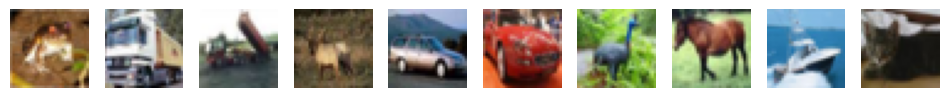

In [6]:
# In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 10, figsize=(12,6))
for i in range(10):
    ax[i].set_axis_off()
    ax[i].imshow(x_train[i])

In [7]:
# In [9]:
y_train[:10]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1],
       [2],
       [7],
       [8],
       [3]], dtype=uint8)

In [8]:
# In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dropout

In [10]:
# In [ ]:
def get_model():
    model = Sequential([
                        Conv2D(filters=64, kernel_size=(3,3), padding='SAME', input_shape=(32,32,3), activation='relu', name='conv_1'),
                        BatchNormalization(),
                        Conv2D(filters=32, kernel_size=(3,3), padding='SAME', activation='relu', name='conv_2'),
                        BatchNormalization(),
                        MaxPooling2D(pool_size=(8,8), name='pool_1'),
                        Dropout(rate=0.5),
                        Flatten(name='flatten_1'),
                        Dense(16, activation='relu', name='dense_1'),
                        Dense(10, activation='softmax', name='classification')

    ])
    opt = tf.optimizers.Adam(learning_rate = 0.005)
    acc = tf.metrics.SparseCategoricalAccuracy()
    model.compile(optimizer=opt,loss='sparse_categorical_crossentropy', metrics = [acc])
    return model

In [11]:
model = get_model()
model.summary()

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-02 13:15:15.147353: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-02 13:15:15.147557: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-02 13:15:15.147562: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1788335115.147969 2985343 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788335115.148330 2985343 pluggable_device_f

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,018 (113.35 KB)

 Trainable params: 28,826 (112.60 KB)

 Non-trainable params: 192 (768.00 B)

In [13]:
import os
import datetime
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

early_stopping = EarlyStopping(patience=5, monitor="val_loss", mode="min")
learning_rate_reduction = ReduceLROnPlateau(patience=4, monitor="val_loss", factor=0.1)

# local checkpoint dir instead of /content/gdrive/...
checkpoint_dir = "./data/model_checkpoints_best"
os.makedirs(checkpoint_dir, exist_ok=True)

# Keras 3 requires this exact suffix when save_weights_only=True
checkpoint_best_path = os.path.join(checkpoint_dir, "checkpoint.weights.h5")

checkpoint_best = ModelCheckpoint(filepath=checkpoint_best_path, save_weights_only=True,
                                   save_freq="epoch", monitor="val_loss",
                                   save_best_only=True,
                                   verbose=1)

log_dir = os.path.join("./data/logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
callbacks = [early_stopping, learning_rate_reduction, checkpoint_best, tensorboard_callback]

In [14]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, callbacks=callbacks)

Epoch 1/10


2026-09-02 13:25:47.567392: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.3692 - sparse_categorical_accuracy: 0.2541
Epoch 1: val_loss improved from None to 2.32749, saving model to ./data/model_checkpoints_best/checkpoint.weights.h5

Epoch 1: finished saving model to ./data/model_checkpoints_best/checkpoint.weights.h5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - loss: 2.3692 - sparse_categorical_accuracy: 0.2541 - val_loss: 2.3275 - val_sparse_categorical_accuracy: 0.2277 - learning_rate: 0.0050
Epoch 2/10
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.3072 - sparse_categorical_accuracy: 0.3037
Epoch 2: val_loss improved from 2.32749 to 2.25386, saving model to ./data/model_checkpoints_best/checkpoint.weights.h5

Epoch 2: finished saving model to ./data/model_checkpoints_best/checkpoint.weights.h5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 2.3068 - sparse_categorical_accuracy: 0.3038 - val_loss: 2.2539 - val_sparse_categorical_accuracy: 0.3238 - learning_rate: 0.0050
Epoch 3/10
1563/15

In [19]:
from tensorboard import program
import os

# Anchor to this notebook's own folder, not whatever os.getcwd() currently
# is (which may have been changed by an earlier os.chdir() cell in this
# kernel session). Adjust NOTEBOOK_DIR only if this doesn't match your
# actual project root.
NOTEBOOK_DIR = "/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2"

log_dir = os.path.join(NOTEBOOK_DIR, "data", "logs")

print("Current working directory:", os.getcwd())
print("Looking for logs in:", log_dir)
print("log_dir exists:", os.path.isdir(log_dir))
if os.path.isdir(log_dir):
    print("Contents of log_dir:", os.listdir(log_dir))

tb = program.TensorBoard()
tb.configure(argv=[None, "--logdir", log_dir])
url = tb.launch()
print(f"TensorBoard running at: {url}")

Current working directory: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/data
Looking for logs in: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/data/logs
log_dir exists: True
Contents of log_dir: ['20260902-132527']
TensorBoard running at: http://localhost:6009/


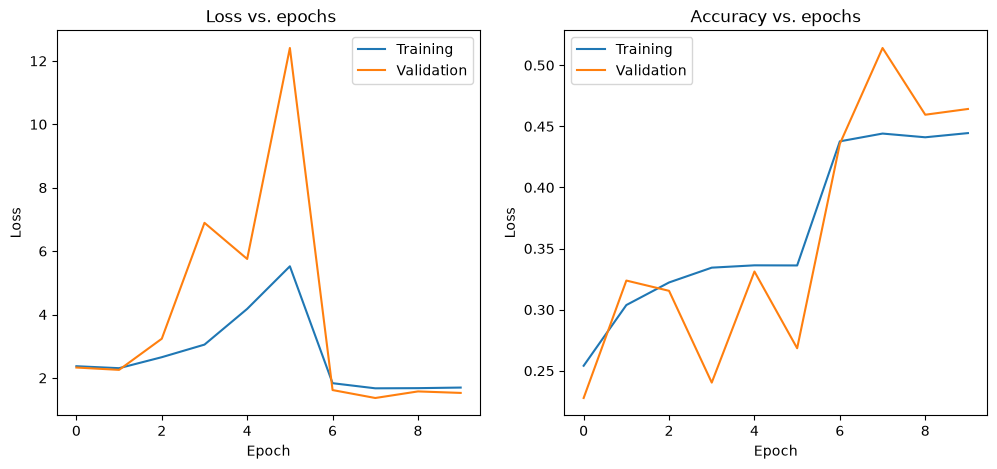

In [20]:
# In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title(' Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

fig.add_subplot(122)

plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

plt.show()

In [21]:
# In [18]:
def get_test_accuracy(model, x_test, y_test):
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return test_loss, test_acc

In [22]:
# In [19]:
test_loss, test_accuracy = get_test_accuracy(model, x_test, y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

Test loss: 1.5268296003341675
Test accuracy: 0.4641999900341034


In [25]:
import os

NOTEBOOK_DIR = "/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2"

checkpoint_best_path = os.path.join(NOTEBOOK_DIR, "data", "model_checkpoints_best", "checkpoint.weights.h5")
print("Checkpoint exists:", os.path.isfile(checkpoint_best_path))  # should print True

model1 = get_model()
model1.load_weights(checkpoint_best_path)
test_loss, test_accuracy = get_test_accuracy(model1, x_test, y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

Checkpoint exists: True


/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_2', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(store)


Test loss: 1.366548776626587
Test accuracy: 0.5141000151634216


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


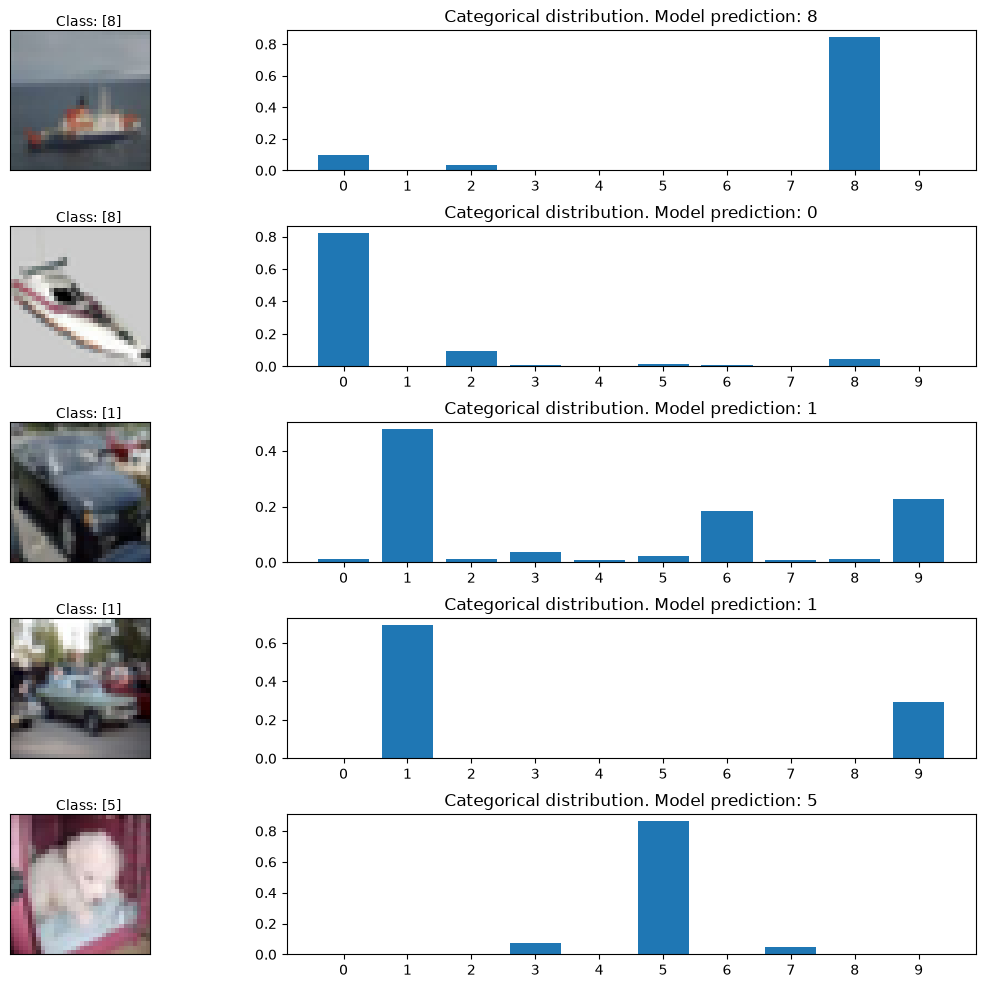

In [ ]:
# In [ ]:
import numpy as np

num_test_images = y_test.shape[0]

random_inx = np.random.choice(num_test_images, 5)
random_test_images = x_test[random_inx, ...]
random_test_labels = y_test[random_inx, ...]

predictions = model1.predict(random_test_images)

fig, axes = plt.subplots(5, 2, figsize=(16, 12))
fig.subplots_adjust(hspace=0.4, wspace=-0.2)

for i, (prediction, images, labels) in enumerate(zip(predictions, random_test_images, random_test_labels)):
    axes[i, 0].imshow(np.squeeze(images))
    axes[i, 0].get_xaxis().set_visible(False)
    axes[i, 0].get_yaxis().set_visible(False)
    axes[i, 0].text(10., -1.5, f'Class: {labels}')
    axes[i, 1].bar(np.arange(len(prediction)), prediction)
    axes[i, 1].set_xticks(np.arange(len(prediction)))
    axes[i, 1].set_title(f"Categorical distribution. Model prediction: {np.argmax(prediction)}")
plt.show()